# Characterization of the pH-Dependent Stabilizing Forces of Insulin’s Monomeric and Fibril States  
Stefan Hervø-Hansen<sup>a</sup> and Nobuyuki Matubayasi<sup>a</sup><br><br>
<sup>a</sup>Division of Chemical Engineering, Graduate School of Engineering Science, The University of Osaka, Toyonaka, Osaka 560-8531, Japan.<br>
*Correspondence:* stefan@cheng.es.osaka-u.ac.jp, nobuyuki@cheng.es.osaka-u.ac.jp

---

## Equilibration Analysis
**Purpose:** Evaluate energy, temperature, and density relaxation.

---

### Project Notebook Index

| Notebook | Description |
|---------|-------------|
| [Simulations](./Simulations.ipynb) | Equilibration analysis and simulation quality assessment |
| [Analysis_monomer](./Analysis_monomer.ipynb) | CpHMD analysis of monomeric native insulin |
| [Analysis_fibril_1mer](./Analysis_fibril_1mer.ipynb) | CpHMD analysis of fibril protofilament (1-mer) |
| [Analysis_fibril_3mer](./Analysis_fibril_3mer.ipynb) | CpHMD analysis of fibril trimer (3-mer) |
| [Analysis_fibril_7mer](./Analysis_fibril_7mer.ipynb) | CpHMD analysis of fibril heptamer (7-mer) |

---

### Module Loading and Function Definitions

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import mdtraj as md
from scipy import stats
from scipy import optimize
from IPython.display import Markdown
import re


mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.default'] = 'regular'


In [2]:
Simulations = {
    'monomer':  {'dir_name': 'monomer',  'filename': 'insulin'},        # monomeric native insulin
    'fibril_1': {'dir_name': 'fibril_1', 'filename': 'insulin_fibril'}, # monomeric protofibril
    'fibril_3': {'dir_name': 'fibril_3', 'filename': 'insulin_fibril'}, # trimeric protofibril
    'fibril_7': {'dir_name': 'fibril_7', 'filename': 'insulin_fibril'}, # heptameric protofibril
}

## Equilibration analysis
### Minimization

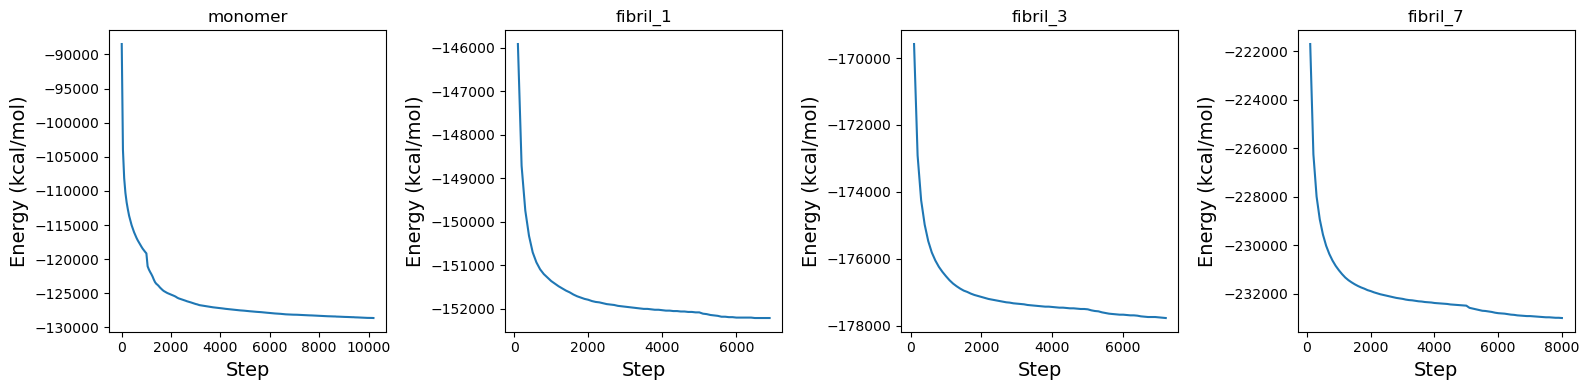

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=len(Simulations), figsize=(4*len(Simulations), 4))

for i, (simulation_name, simulation_attributes) in enumerate(Simulations.items()):
    with open('{}/1_minimization/{}.min.mdout'.format(simulation_attributes['dir_name'], simulation_attributes['filename']), 'r') as f:
        lines = f.readlines()
    f.close()
    
    Nsteps     = []
    observable = []

    data_collection = False
    for j, line in enumerate(lines):
        ## Check for start and stop data collection
        if 'RESULTS' in line: # Start
            data_collection = True
            
        if re.search('A V E R A G E S', line) or re.search('FINAL RESULTS', line): # Stop
            data_collection = False 
        
        ## Do data collection
        if 'ENERGY' in line and data_collection==True:
            Nsteps.append(float(lines[j+1].split()[0]))
            observable.append(float(lines[j+1].split()[1]))
            
    
    # Visualize data and simulation specific edits
    if i != 0:
        axes[i].plot(Nsteps[1:], np.array(observable)[1:])
    else:
        axes[i].plot(Nsteps, np.array(observable))

    axes[i].set_title(simulation_name)

# Beautification
for ax in axes:
    ax.set_xlabel('Step', fontsize=14)
    ax.set_ylabel('Energy (kcal/mol)', fontsize=14)
    
    
fig.tight_layout()


### Heating

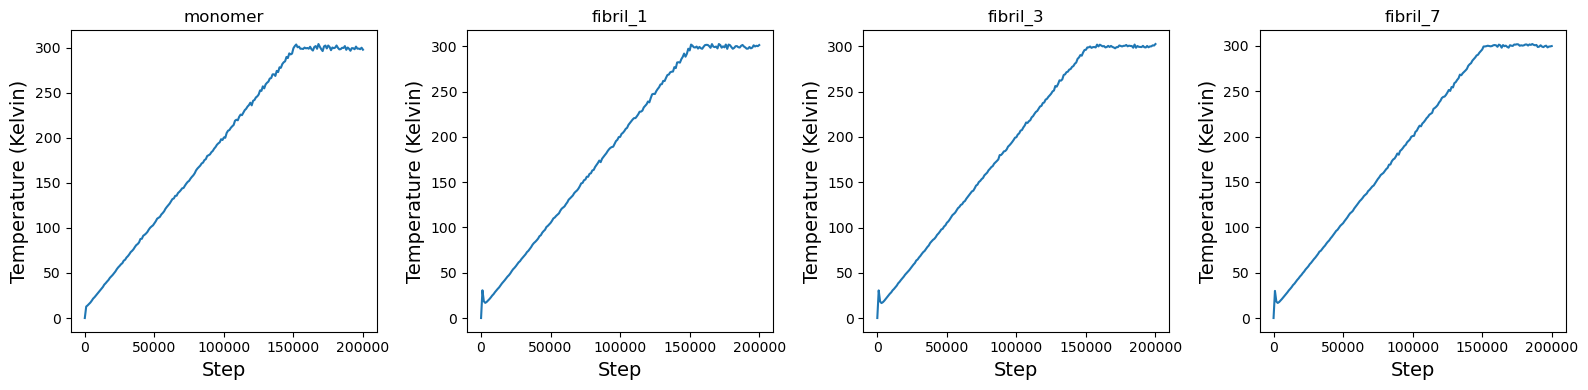

In [25]:
fig, axes = plt.subplots(nrows=1, ncols=len(Simulations), figsize=(4*len(Simulations), 4))

for i, (simulation_name, simulation_attributes) in enumerate(Simulations.items()):
    with open('{}/2_heating/{}.heat.mdout'.format(simulation_attributes['dir_name'], simulation_attributes['filename']), 'r') as f:
        lines = f.readlines()
    f.close()
    
    Nsteps     = []
    observable = []

    data_collection = False
    for j, line in enumerate(lines):
        ## Check for start and stop data collection
        if 'RESULTS' in line: # Start
            data_collection = True
            
        if re.search('A V E R A G E S', line) or re.search('FINAL RESULTS', line): # Stop
            data_collection = False 
        
        ## Do data collection
        if 'TEMP(K)' in line and data_collection==True:
            Nsteps.append(float(line.split()[2]))
            observable.append(float(line.split()[8]))
            
    
    # Visualize data and simulation specific edits
    axes[i].plot(Nsteps, np.array(observable))
    axes[i].set_title(simulation_name)

# Beautification
for ax in axes:
    ax.set_xlabel('Step', fontsize=14)
    ax.set_ylabel('Temperature (Kelvin)', fontsize=14)
    
    
fig.tight_layout()


### Volume equilibration

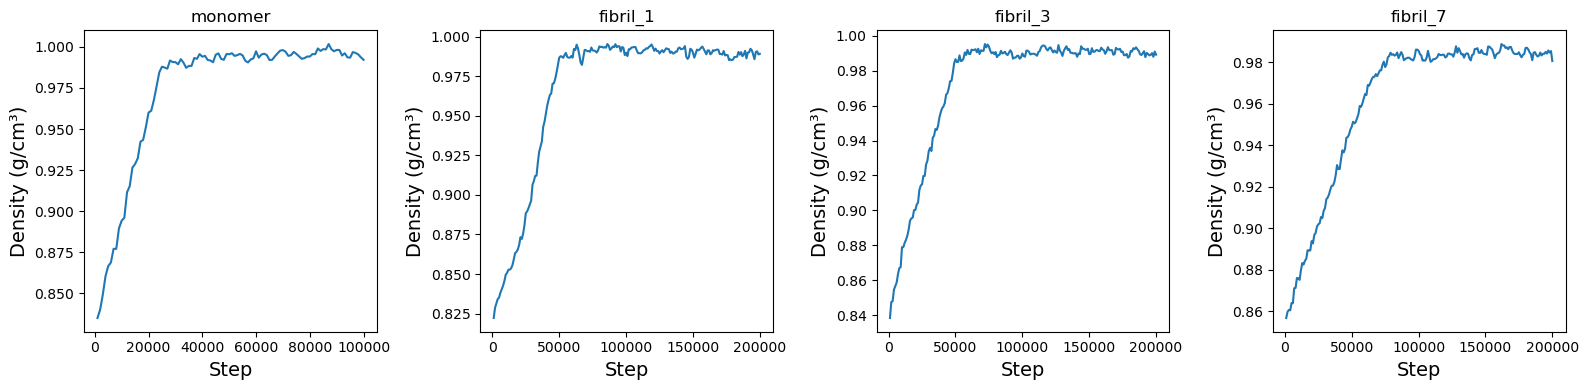

In [26]:
fig, axes = plt.subplots(nrows=1, ncols=len(Simulations), figsize=(4*len(Simulations), 4))

for i, (simulation_name, simulation_attributes) in enumerate(Simulations.items()):
    with open('{}/3_equilibration/{}.equil.mdout'.format(simulation_attributes['dir_name'], simulation_attributes['filename']), 'r') as f:
        lines = f.readlines()
    f.close()
    
    Nsteps     = []
    observable = []

    data_collection = False
    for j, line in enumerate(lines):
        ## Check for start and stop data collection
        if 'RESULTS' in line: # Start
            data_collection = True
            
        if re.search('A V E R A G E S', line) or re.search('FINAL RESULTS', line): # Stop
            data_collection = False 
        
        ## Do data collection
        if 'NSTEP' in line and data_collection==True:
            Nsteps.append(float(line.split()[2]))
        if 'Density' in line and data_collection==True:
            observable.append(float(line.split()[2]))
            
    
    # Visualize data and simulation specific edits
    axes[i].plot(Nsteps, np.array(observable))
    axes[i].set_title(simulation_name)

# Beautification
for ax in axes:
    ax.set_xlabel('Step', fontsize=14)
    ax.set_ylabel('Density (g/cm³)', fontsize=14)
    
    
fig.tight_layout()
